# SAM3 Segmentation with OpenVINO FP16

[SAM3](https://huggingface.co/facebook/sam3) from Meta is a unified open-vocabulary segmentation model combining a CLIP text encoder, ViT+FPN image encoder, and a DETR-style decoder. It predicts up to 200 instance masks, bounding boxes, and a semantic segmentation map from a single text + image input.

This notebook demonstrates:
- Loading SAM3 from the local HuggingFace cache
- Running PyTorch CPU inference as the accuracy baseline
- **Converting on-the-fly** to OpenVINO FP16 IR (with trace-safe mask patches for transformers 5.x)
- Selecting inference device: **CPU / GPU / NPU** via a widget
- Quantitative accuracy check (cosine similarity + mask IoU)
- Visualising instance masks, boxes, and semantic segmentation
- End-to-end latency benchmarking


### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks/sam3-segmentation/sam3-ov-fp16.ipynb" />

#### Table of contents:

- [1. Prerequisites <a id="prerequisites"></a>](#1.-Prerequisites-<a-id="prerequisites"></a>)
- [2. Configuration & Paths <a id="configuration"></a>](#2.-Configuration-&-Paths-<a-id="configuration"></a>)
- [3. Load SAM3 PyTorch Model <a id="load-model"></a>](#3.-Load-SAM3-PyTorch-Model-<a-id="load-model"></a>)
- [4. Prepare Test Input <a id="prepare-input"></a>](#4.-Prepare-Test-Input-<a-id="prepare-input"></a>)
- [5. PyTorch Reference Inference <a id="pytorch-inference"></a>](#5.-PyTorch-Reference-Inference-<a-id="pytorch-inference"></a>)
- [6. Convert to OpenVINO FP16 <a id="convert-fp16"></a>](#6.-Convert-to-OpenVINO-FP16-<a-id="convert-fp16"></a>)
- [7. Select Inference Device <a id="select-device"></a>](#7.-Select-Inference-Device-<a-id="select-device"></a>)
- [8. Accuracy Check <a id="accuracy-check"></a>](#8.-Accuracy-Check-<a-id="accuracy-check"></a>)
- [9. Visualise Predictions <a id="visualise"></a>](#9.-Visualise-Predictions-<a-id="visualise"></a>)
- [10. Performance Benchmark <a id="benchmark"></a>](#10.-Performance-Benchmark-<a-id="benchmark"></a>)
- [Summary](#Summary)

## 1. Prerequisites <a id="prerequisites"></a>
[back to top ⬆️](#Table-of-contents:)

Install required packages. Model weights are loaded from the local HuggingFace cache (offline, no network needed).

In [ ]:
%pip install -q "openvino>=2026.1.0" "torch>=2.8" "transformers>=5.0" "numpy" "Pillow" "matplotlib" "ipywidgets" "scipy"

import os
import requests
from pathlib import Path

os.environ.setdefault("HF_HUB_OFFLINE", "1")
os.environ.setdefault("TRANSFORMERS_OFFLINE", "1")
os.environ.setdefault("HF_HOME", os.path.expanduser("~/.cache/huggingface"))
os.environ.setdefault("OMP_NUM_THREADS", "4")  # limit threads during conversion (~14 GB RAM peak)

if not Path("notebook_utils.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py",
    )
    open("notebook_utils.py", "w").write(r.text)

# Read more about telemetry collection at
# https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("sam3-ov-fp16.ipynb")

print("\u2713 Environment ready")

Note: you may need to restart the kernel to use updated packages.
✓ Environment ready


## 2. Configuration & Paths <a id="configuration"></a>
[back to top ⬆️](#Table-of-contents:)

Central place for all paths, shapes, and constants.

In [ ]:
from pathlib import Path

import numpy as np

WORK_DIR = Path().resolve()
FP16_XML = WORK_DIR / "fp16" / "sam3_full.xml"
CACHE_DIR = WORK_DIR / "fp16" / ".ov_cache"
COCO_IMGS = WORK_DIR / "coco" / "val2017"

MODEL_ID = "facebook/sam3"
IMG_SIZE = 1008
TEXT_LEN = 32
MASK_SIZE = 288
NUM_QUERIES = 200
TEXT_PROMPT = "ear"
OUTPUT_NAMES = ["pred_masks", "pred_boxes", "pred_logits", "presence_logits", "semantic_seg"]

(WORK_DIR / "fp16").mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

print(f"\u2713 Work dir  : {WORK_DIR}")
print(f"\u2713 FP16 path : {FP16_XML}")
print(f"\u2713 Cache dir : {CACHE_DIR}")

✓ Work dir  : /home/user/parual/sam3_ov
✓ FP16 path : /home/user/parual/sam3_ov/fp16/sam3_full.xml
✓ Cache dir : /home/user/parual/sam3_ov/fp16/.ov_cache


## 3. Load SAM3 PyTorch Model <a id="load-model"></a>
[back to top ⬆️](#Table-of-contents:)

Load the SAM3 model and processor from the local HuggingFace cache in `float32` for a clean CPU reference.

In [ ]:
import torch
from transformers import Sam3Model, Sam3Processor

print(f"Loading {MODEL_ID} ...")
processor = Sam3Processor.from_pretrained(MODEL_ID)
pt_model = Sam3Model.from_pretrained(MODEL_ID, torch_dtype=torch.float32)
pt_model.eval()
torch.set_grad_enabled(False)

total_params = sum(p.numel() for p in pt_model.parameters())
print(f"\u2713 Loaded : {type(pt_model).__name__}")
print(f"  Params  : {total_params / 1e6:.1f} M")
print(f"  Processor: {type(processor).__name__}")

Loading facebook/sam3 ...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

✓ Loaded : Sam3Model
  Params  : 840.4 M
  Processor: Sam3Processor


## 4. Prepare Test Input <a id="prepare-input"></a>
[back to top ⬆️](#Table-of-contents:)

Load COCO val2017 image `000000267191.jpg` and preprocess with text prompt **"ear"** using the SAM3 processor.

✓ Using cached image: /home/user/parual/sam3_ov/coco/val2017/000000267191.jpg
✓ Image : 000000267191.jpg  640×480
  pixel_values  : (1, 3, 1008, 1008)  float32
  input_ids     : (1, 32)  int64
  attention_mask: (1, 32)  int64


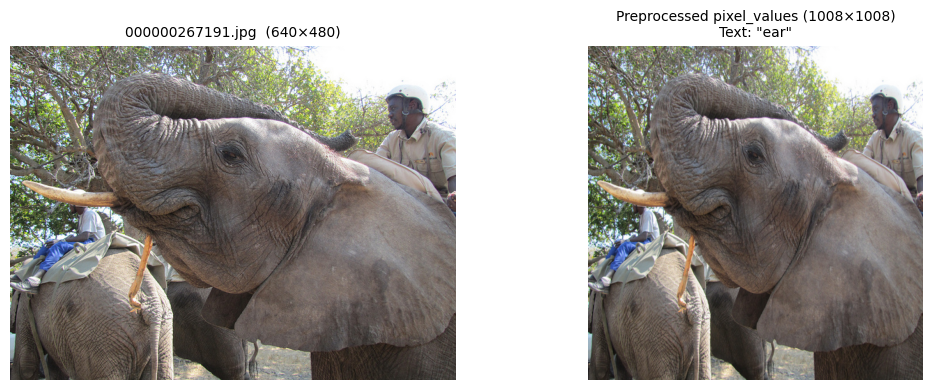

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import urllib.request
from PIL import Image

IMG_NAME = "000000267191.jpg"
COCO_URL = f"http://images.cocodataset.org/val2017/{IMG_NAME}"
img_path = COCO_IMGS / IMG_NAME

if not img_path.exists():
    img_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {COCO_URL} ...")
    urllib.request.urlretrieve(COCO_URL, img_path)
    print(f"\u2713 Downloaded \u2192 {img_path}")
else:
    print(f"\u2713 Using cached image: {img_path}")

raw_image = Image.open(img_path).convert("RGB")
print(f"\u2713 Image : {img_path.name}  {raw_image.size[0]}\u00d7{raw_image.size[1]}")

inputs = processor(images=raw_image, text=TEXT_PROMPT, return_tensors="pt")
pixel_values = inputs["pixel_values"]  # [1, 3, 1008, 1008]
input_ids = inputs["input_ids"]  # [1, seq]
attention_mask = inputs["attention_mask"]  # [1, seq]

# Pad/trim to fixed TEXT_LEN for the static-shape OV model
seq = input_ids.shape[1]
pad_id = processor.tokenizer.pad_token_id or 0
if seq < TEXT_LEN:
    input_ids = F.pad(input_ids, (0, TEXT_LEN - seq), value=pad_id)
    attention_mask = F.pad(attention_mask, (0, TEXT_LEN - seq), value=0)
else:
    input_ids = input_ids[:, :TEXT_LEN]
    attention_mask = attention_mask[:, :TEXT_LEN]

# numpy for OpenVINO
np_pv = pixel_values.numpy().astype(np.float32)  # [1,3,1008,1008]
np_ids = input_ids.numpy().astype(np.int64)  # [1,32]
np_att = attention_mask.numpy().astype(np.int64)  # [1,32]

print(f"  pixel_values  : {np_pv.shape}  {np_pv.dtype}")
print(f"  input_ids     : {np_ids.shape}  {np_ids.dtype}")
print(f"  attention_mask: {np_att.shape}  {np_att.dtype}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(raw_image)
axes[0].set_title(f"{img_path.name}  ({raw_image.size[0]}\u00d7{raw_image.size[1]})", fontsize=10)
axes[0].axis("off")
pv_disp = np_pv[0].transpose(1, 2, 0)
pv_disp = (pv_disp - pv_disp.min()) / (pv_disp.max() - pv_disp.min())
axes[1].imshow(pv_disp)
axes[1].set_title(f'Preprocessed pixel_values ({IMG_SIZE}\u00d7{IMG_SIZE})\nText: "{TEXT_PROMPT}"', fontsize=10)
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 5. PyTorch Reference Inference <a id="pytorch-inference"></a>
[back to top ⬆️](#Table-of-contents:)

Run the original PyTorch model on CPU to obtain ground-truth outputs used for accuracy comparison (~18 s).

In [ ]:
import time

import scipy.special as sps

print("Running PyTorch CPU inference (~18 s) ...")
t0 = time.perf_counter()

with torch.no_grad():
    pt_out = pt_model(
        pixel_values=pixel_values,
        input_ids=input_ids,
        attention_mask=attention_mask,
    )

pt_elapsed = time.perf_counter() - t0

ref_pred_masks = pt_out.pred_masks.numpy()  # [1,200,288,288]
ref_pred_boxes = pt_out.pred_boxes.numpy()  # [1,200,4]
ref_pred_logits = pt_out.pred_logits.numpy()  # [1,200] or [1,200,1]
ref_presence_logits = pt_out.presence_logits.numpy()  # [1,1]
ref_semantic_seg = pt_out.semantic_seg.numpy()  # [1,1,288,288]

if ref_pred_logits.ndim == 3:
    ref_pred_logits = ref_pred_logits.squeeze(-1)

scores = sps.expit(ref_pred_logits[0])
top_idx = int(np.argmax(scores))

print(f"\u2713 Done in {pt_elapsed:.1f}s")
print(f"  pred_masks      : {ref_pred_masks.shape}")
print(f"  pred_boxes      : {ref_pred_boxes.shape}")
print(f"  pred_logits     : {ref_pred_logits.shape}")
print(f"  presence_logits : {ref_presence_logits.shape}")
print(f"  semantic_seg    : {ref_semantic_seg.shape}")
print(f"  Top query #{top_idx}: score={scores[top_idx]:.4f}")

Running PyTorch CPU inference (~18 s) ...
✓ Done in 14.4s
  pred_masks      : (1, 200, 288, 288)
  pred_boxes      : (1, 200, 4)
  pred_logits     : (1, 200)
  presence_logits : (1, 1)
  semantic_seg    : (1, 1, 288, 288)
  Top query #25: score=0.8980


## 6. Convert to OpenVINO FP16 <a id="convert-fp16"></a>
[back to top ⬆️](#Table-of-contents:)

Convert the PyTorch model on-the-fly to OpenVINO IR with FP16 weight compression.

**Key steps:**
- **Trace-safe mask patches** — `transformers 5.x` `sdpa_mask` crashes under `torch.jit` tracing; replaced with numerically-identical additive masks (verified diff == 0.0)
- **`Sam3Wrapper`** — returns a plain tuple instead of the HF dataclass (required for `ov.convert_model`)
- **Static shapes** `[1,3,1008,1008]` for optimal GPU/NPU kernel compilation
- **`compress_to_fp16=True`** — halves model size from ~3.3 GB to ~1.7 GB

> Re-running this cell skips conversion if the IR already exists.

In [ ]:
import time

import openvino as ov
import torch


# ── Trace-safe mask patches (transformers 5.x tracing bug) ───────────────────
def install_trace_safe_masks():
    import transformers.models.clip.modeling_clip as clip_mod
    import transformers.models.sam3.modeling_sam3 as sam3_mod

    def trace_safe_causal_mask(config=None, inputs_embeds=None, attention_mask=None, **kwargs):
        bsz, seq = inputs_embeds.shape[0], inputs_embeds.shape[1]
        dtype, device = inputs_embeds.dtype, inputs_embeds.device
        mv = torch.finfo(dtype).min
        causal = torch.full((seq, seq), mv, dtype=dtype, device=device).triu(1)
        causal = causal[None, None].expand(bsz, 1, seq, seq)
        if attention_mask is not None:
            pad = (1.0 - attention_mask[:, None, None, :].to(dtype)) * mv
            causal = causal + pad
        return causal

    def trace_safe_bidirectional_mask(
        config=None,
        inputs_embeds=None,
        attention_mask=None,
        encoder_hidden_states=None,
        **kwargs,
    ):
        if attention_mask is None:
            return None
        dtype, device = inputs_embeds.dtype, inputs_embeds.device
        bsz, q_len = inputs_embeds.shape[0], inputs_embeds.shape[1]
        kv_len = (
            encoder_hidden_states.shape[1] if encoder_hidden_states is not None else attention_mask.shape[1]
        )
        mv = torch.finfo(dtype).min
        mask = (1.0 - attention_mask[:, None, None, :].to(dtype)) * mv
        return mask.expand(bsz, 1, q_len, kv_len)

    clip_mod.create_causal_mask = trace_safe_causal_mask
    sam3_mod.create_bidirectional_mask = trace_safe_bidirectional_mask
    print("\u2713 Trace-safe mask patches installed")


# ── Model wrapper (plain-tuple output for OV) ─────────────────────────────────
class Sam3Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, pixel_values, input_ids, attention_mask):
        out = self.model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        return (out.pred_masks, out.pred_boxes, out.pred_logits, out.presence_logits, out.semantic_seg)


# ── Convert (skip if already cached) ──────────────────────────────────────────

install_trace_safe_masks()
wrapper = Sam3Wrapper(pt_model).eval()
print("Converting SAM3 \u2192 OpenVINO IR  (~2 min, ~14 GB RAM) ...")
t0 = time.perf_counter()
ov_model = ov.convert_model(
    wrapper,
    example_input=(pixel_values, input_ids, attention_mask),
    input=[
        ("pixel_values", ov.PartialShape([1, 3, IMG_SIZE, IMG_SIZE]), ov.Type.f32),
        ("input_ids", ov.PartialShape([1, TEXT_LEN]), ov.Type.i64),
        ("attention_mask", ov.PartialShape([1, TEXT_LEN]), ov.Type.i64),
    ],
)
print(f"  export done  ({time.perf_counter() - t0:.0f}s)")
for port, name in zip(ov_model.outputs, OUTPUT_NAMES):
    port.get_tensor().set_names({name})
ov.save_model(ov_model, str(FP16_XML), compress_to_fp16=True)
fp16_mb = (FP16_XML.stat().st_size + FP16_XML.with_suffix(".bin").stat().st_size) / 1024**2
print(f"\u2713 Saved {FP16_XML}  ({fp16_mb:.1f} MB)  total {time.perf_counter() - t0:.0f}s")

# ── Inspect IR ────────────────────────────────────────────────────────────────
core = ov.Core()
ov_model = core.read_model(str(FP16_XML))
print("\n\u2500\u2500 Inputs")
for inp in ov_model.inputs:
    print(f"  {inp.get_any_name():20s} {str(inp.partial_shape):25s} {inp.element_type}")
print("\u2500\u2500 Outputs")
for out in ov_model.outputs:
    print(f"  {out.get_any_name():20s} {str(out.partial_shape):25s} {out.element_type}")
ops = {}
for op in ov_model.get_ops():
    ops[op.get_type_name()] = ops.get(op.get_type_name(), 0) + 1
print(f"\n  Total ops: {sum(ops.values())}")
for t in ["MatMul", "Convolution", "Constant"]:
    print(f"  {t:15s}: {ops.get(t, 0)}")
print(f"\n\u2713 FP16 IR ready  ({fp16_mb:.1f} MB)")

✓ Trace-safe mask patches installed
Converting SAM3 → OpenVINO IR  (~2 min, ~14 GB RAM) ...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


✓ Trace-safe mask patches installed
Converting SAM3 → OpenVINO IR  (~2 min, ~14 GB RAM) ...


/home/user/miniforge3/lib/python3.13/site-packages/transformers/models/sam3/modeling_sam3.py:604: TracerWarning: Converting a tensor to a Python integer might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  pretrain_size = int(position_embeddings.shape[1] ** 0.5)
/home/user/miniforge3/lib/python3.13/site-packages/transformers/integrations/sdpa_attention.py:77: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  is_causal = query.shape[2] > 1 and attention_mask is None and is_causal
/home/user/miniforge3/lib/python3.13/site-packages/transformers/models/clip/modeling_clip.py:243: TracerWarning: Converting a tensor to a Py

  export done  (78s)
✓ Saved /home/user/parual/sam3_ov/fp16/sam3_full.xml  (1614.9 MB)  total 79s
  export done  (78s)
  export done  (78s)
✓ Saved /home/user/parual/sam3_ov/fp16/sam3_full.xml  (1614.9 MB)  total 79s

── Inputs
  153                  [1,3,1008,1008]           <Type: 'float32'>
  input_ids            [1,32]                    <Type: 'int64_t'>
  5324                 [1,32]                    <Type: 'int64_t'>
── Outputs
  pred_masks           [1,200,288,288]           <Type: 'float32'>
  pred_boxes           [1,200,4]                 <Type: 'float32'>
  pred_logits          [1,200]                   <Type: 'float32'>
  presence_logits      [1,1]                     <Type: 'float32'>
  semantic_seg         [1,1,288,288]             <Type: 'float32'>

  Total ops: 9349
  MatMul         : 541
  Convolution    : 11
  Constant       : 3369

✓ FP16 IR ready  (1614.9 MB)


## 7. Select Inference Device <a id="select-device"></a>
[back to top ⬆️](#Table-of-contents:)

Choose the target device. **GPU** gives the best latency (~420 ms on Intel iGPU Xe2). **NPU** may not support all ops in this 900 M-parameter model and falls back gracefully.

In [ ]:
from notebook_utils import device_widget

device = device_widget()

device

Available devices:
  CPU: Intel(R) Core(TM) Ultra X9 388H
  GPU: Intel(R) Graphics [0xb082] (iGPU)
  NPU: Intel(R) AI Boost


Dropdown(description='Device:', options=('GPU', 'CPU', 'NPU', 'AUTO'), style=DescriptionStyle(description_widt…

In [ ]:
import time

import openvino as ov

DEVICE = device.value
print(f"Compiling SAM3 FP16 for {DEVICE} ...")

core = ov.Core()
core.set_property({"CACHE_DIR": str(CACHE_DIR)})

t0 = time.perf_counter()
try:
    compiled = core.compile_model(str(FP16_XML), DEVICE, {"PERFORMANCE_HINT": "LATENCY"})
    print(f"\u2713 Compiled on {DEVICE} in {time.perf_counter() - t0:.1f}s  (cached: <2s next run)")
except Exception as e:
    print(f"\u2717 {DEVICE} failed: {e}")
    fallback = "GPU" if "GPU" in core.available_devices else "CPU"
    print(f"  Falling back to {fallback} ...")
    DEVICE = fallback
    compiled = core.compile_model(str(FP16_XML), DEVICE, {"PERFORMANCE_HINT": "LATENCY"})
    print(f"\u2713 Compiled on {DEVICE} in {time.perf_counter() - t0:.1f}s")

Compiling SAM3 FP16 for GPU ...
✓ Compiled on GPU in 6.3s  (cached: <2s next run)


## 8. Accuracy Check <a id="accuracy-check"></a>
[back to top ⬆️](#Table-of-contents:)

Compare OV FP16 outputs against the PyTorch CPU reference.

| Metric | Pass threshold | Description |
|--------|---------------|-------------|
| Cosine similarity | > 0.999 | Directional alignment per output tensor |
| Instance mask IoU | > 0.90 | Binary mask overlap (logit > 0) on best query |
| Semantic seg IoU  | > 0.90 | Semantic map binary overlap |

In [ ]:
import numpy as np
import openvino as ov


def cosine_sim(a, b):
    a = a.flatten().astype(np.float32)
    b = b.flatten().astype(np.float32)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))


def mask_iou(a, b, thr=0.0):
    a_b = a > thr
    b_b = b > thr
    inter = np.logical_and(a_b, b_b).sum()
    union = np.logical_or(a_b, b_b).sum()
    return float(inter / union) if union > 0 else 1.0


# Fresh request avoids presence_logits shape mismatch on GPU plugin
print(f"Running OV FP16 on {DEVICE} ...")
req = compiled.create_infer_request()
req.set_tensor("pixel_values", ov.Tensor(np_pv))
req.set_tensor("input_ids", ov.Tensor(np_ids))
req.set_tensor("attention_mask", ov.Tensor(np_att))
req.infer()


def get_out(name):
    for out in compiled.outputs:
        if name in out.get_names():
            return req.get_tensor(out).data.copy()
    raise KeyError(name)


ov_pred_masks = get_out("pred_masks")
ov_pred_boxes = get_out("pred_boxes")
ov_pred_logits = get_out("pred_logits")
ov_presence_logits = get_out("presence_logits").reshape(ref_presence_logits.shape)
ov_semantic_seg = get_out("semantic_seg")
if ov_pred_logits.ndim == 3:
    ov_pred_logits = ov_pred_logits.squeeze(-1)

print("\u2713 Inference done\n")
pairs = [
    ("pred_masks", ov_pred_masks, ref_pred_masks),
    ("pred_boxes", ov_pred_boxes, ref_pred_boxes),
    ("pred_logits", ov_pred_logits, ref_pred_logits),
    ("presence_logits", ov_presence_logits, ref_presence_logits),
    ("semantic_seg", ov_semantic_seg, ref_semantic_seg),
]
print(f"\u2500\u2500 Accuracy: OV FP16 ({DEVICE}) vs PyTorch CPU")
accuracy_results = {}
all_pass = True
for name, ov_t, ref_t in pairs:
    cos = cosine_sim(ov_t, ref_t)
    ok = cos > 0.99
    if not ok:
        all_pass = False
    accuracy_results[name] = {"cosine": cos}
    print(f'  {"\u2713" if ok else "\u2717"} {name:20s}  cosine={cos:.6f}')

top_mask_iou = mask_iou(ov_pred_masks[0, top_idx], ref_pred_masks[0, top_idx])
semseg_iou = mask_iou(ov_semantic_seg[0, 0], ref_semantic_seg[0, 0])
accuracy_results["pred_masks"]["iou_top"] = top_mask_iou
accuracy_results["semantic_seg"]["iou"] = semseg_iou
if not (top_mask_iou > 0.90 and semseg_iou > 0.90):
    all_pass = False
print(f'  {"\u2713" if top_mask_iou > 0.90 else "\u2717"} pred_masks top IoU   : {top_mask_iou:.4f}')
print(f'  {"\u2713" if semseg_iou > 0.90 else "\u2717"} semantic_seg IoU     : {semseg_iou:.4f}')
print("\n" + "=" * 60)
print("\u2713 ACCURACY CHECK PASSED" if all_pass else "\u26a0 ACCURACY CHECK: Review results above")
print("=" * 60)

Running OV FP16 on GPU ...
✓ Inference done

── Accuracy: OV FP16 (GPU) vs PyTorch CPU
  ✓ pred_masks            cosine=0.995718
  ✓ pred_boxes            cosine=0.998799
  ✓ pred_logits           cosine=0.999440
  ✓ presence_logits       cosine=1.000000
  ✓ semantic_seg          cosine=0.999996
  ✓ pred_masks top IoU   : 0.9999
  ✓ semantic_seg IoU     : 0.9998

✓ ACCURACY CHECK PASSED


## 9. Visualise Predictions <a id="visualise"></a>
[back to top ⬆️](#Table-of-contents:)

Overlay top detected instances (score > 0.30) and semantic segmentation for both PyTorch CPU and OV FP16.

OV detections (score > 0.30): 5
  query  25: score=0.897  cx=0.503 cy=0.358 w=1.004 h=0.916
  query   3: score=0.652  cx=0.430 cy=0.726 w=0.544 h=0.848
  query   2: score=0.562  cx=0.894 cy=0.161 w=0.917 h=0.195
  query  64: score=0.454  cx=0.000 cy=0.734 w=0.023 h=0.860
  query 183: score=0.320  cx=0.757 cy=0.310 w=0.970 h=0.469
PyTorch detections (score > 0.30): 5
  query  25: score=0.898  cx=0.503 cy=0.358 w=1.004 h=0.916
  query   3: score=0.654  cx=0.430 cy=0.726 w=0.545 h=0.848
  query   2: score=0.562  cx=0.894 cy=0.161 w=0.918 h=0.195
  query  64: score=0.453  cx=0.000 cy=0.734 w=0.023 h=0.860
  query 183: score=0.322  cx=0.757 cy=0.310 w=0.970 h=0.468


/tmp/ipykernel_69187/1112932685.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


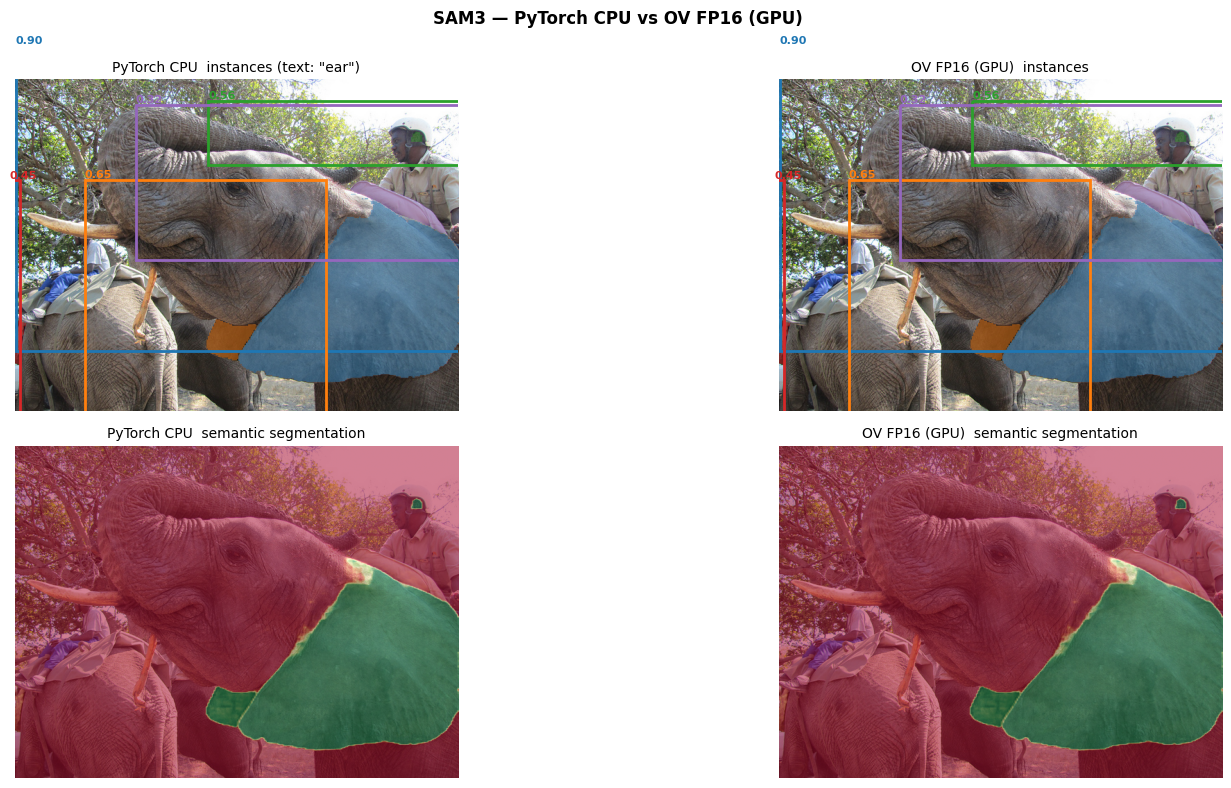

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import scipy.special as sps
from PIL import Image as PILImage

img_arr = np.array(raw_image)
H, W = img_arr.shape[:2]
scores_ov = sps.expit(ov_pred_logits[0])
scores_pt = sps.expit(ref_pred_logits[0])
top_ov = np.where(scores_ov > 0.30)[0]
top_ov = top_ov[np.argsort(scores_ov[top_ov])[::-1]][:5]
top_pt = np.where(scores_pt > 0.30)[0]
top_pt = top_pt[np.argsort(scores_pt[top_pt])[::-1]][:5]
if len(top_ov) == 0:
    top_ov = np.array([int(np.argmax(scores_ov))])
if len(top_pt) == 0:
    top_pt = np.array([int(np.argmax(scores_pt))])
print(f"OV detections (score > 0.30): {len(top_ov)}")
for i in top_ov:
    cx, cy, bw, bh = ov_pred_boxes[0, i]
    print(f"  query {i:3d}: score={scores_ov[i]:.3f}  cx={cx:.3f} cy={cy:.3f} w={bw:.3f} h={bh:.3f}")
print(f"PyTorch detections (score > 0.30): {len(top_pt)}")
for i in top_pt:
    cx, cy, bw, bh = ref_pred_boxes[0, i]
    print(f"  query {i:3d}: score={scores_pt[i]:.3f}  cx={cx:.3f} cy={cy:.3f} w={bw:.3f} h={bh:.3f}")

cmap = plt.cm.get_cmap("tab10")
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# Panel 1: PyTorch CPU instance masks + boxes
axes[0, 0].imshow(img_arr)
for rank, qi in enumerate(top_pt):
    color = cmap(rank % 10)
    mask_bin = (ref_pred_masks[0, qi] > 0.0).astype(np.uint8)
    mask_up = np.array(PILImage.fromarray(mask_bin * 255).resize((W, H), PILImage.NEAREST)) / 255.0
    rgba = np.zeros((H, W, 4), np.float32)
    rgba[..., :3] = color[:3]
    rgba[..., 3] = mask_up * 0.45
    axes[0, 0].imshow(rgba)
    cx, cy, bw, bh = ref_pred_boxes[0, qi]
    x1, y1 = (cx - bw / 2) * W, (cy - bh / 2) * H
    axes[0, 0].add_patch(mpatches.Rectangle((x1, y1), bw * W, bh * H, lw=2, edgecolor=color, facecolor="none"))
    axes[0, 0].text(x1, y1 - 4, f"{scores_pt[qi]:.2f}", color=color, fontsize=8, fontweight="bold")
axes[0, 0].set_title(f'PyTorch CPU  instances (text: "{TEXT_PROMPT}")', fontsize=10)
axes[0, 0].axis("off")

# Panel 2: OV FP16 instance masks + boxes
axes[0, 1].imshow(img_arr)
for rank, qi in enumerate(top_ov):
    color = cmap(rank % 10)
    mask_bin = (ov_pred_masks[0, qi] > 0.0).astype(np.uint8)
    mask_up = np.array(PILImage.fromarray(mask_bin * 255).resize((W, H), PILImage.NEAREST)) / 255.0
    rgba = np.zeros((H, W, 4), np.float32)
    rgba[..., :3] = color[:3]
    rgba[..., 3] = mask_up * 0.45
    axes[0, 1].imshow(rgba)
    cx, cy, bw, bh = ov_pred_boxes[0, qi]
    x1, y1 = (cx - bw / 2) * W, (cy - bh / 2) * H
    axes[0, 1].add_patch(mpatches.Rectangle((x1, y1), bw * W, bh * H, lw=2, edgecolor=color, facecolor="none"))
    axes[0, 1].text(x1, y1 - 4, f"{scores_ov[qi]:.2f}", color=color, fontsize=8, fontweight="bold")
axes[0, 1].set_title(f"OV FP16 ({DEVICE})  instances", fontsize=10)
axes[0, 1].axis("off")

# Panel 3: PyTorch CPU semantic segmentation
axes[1, 0].imshow(img_arr)
seg_prob_pt = sps.expit(ref_semantic_seg[0, 0]).astype(np.float32)
seg_up_pt = np.array(PILImage.fromarray((seg_prob_pt * 255).astype(np.uint8)).resize((W, H), PILImage.BILINEAR))
axes[1, 0].imshow(seg_up_pt, alpha=0.5, cmap="RdYlGn", vmin=0, vmax=255)
axes[1, 0].set_title("PyTorch CPU  semantic segmentation", fontsize=10)
axes[1, 0].axis("off")

# Panel 4: OV FP16 semantic segmentation
axes[1, 1].imshow(img_arr)
seg_prob_ov = sps.expit(ov_semantic_seg[0, 0]).astype(np.float32)
seg_up_ov = np.array(PILImage.fromarray((seg_prob_ov * 255).astype(np.uint8)).resize((W, H), PILImage.BILINEAR))
axes[1, 1].imshow(seg_up_ov, alpha=0.5, cmap="RdYlGn", vmin=0, vmax=255)
axes[1, 1].set_title(f"OV FP16 ({DEVICE})  semantic segmentation", fontsize=10)
axes[1, 1].axis("off")

plt.suptitle(f"SAM3 \u2014 PyTorch CPU vs OV FP16 ({DEVICE})", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Performance Benchmark <a id="benchmark"></a>
[back to top ⬆️](#Table-of-contents:)

Single timed run for both PyTorch CPU and OV FP16, with a comparison table.

In [ ]:
import time

import numpy as np
import openvino as ov


def single_infer():
    req = compiled.create_infer_request()
    req.set_tensor("pixel_values", ov.Tensor(np_pv))
    req.set_tensor("input_ids", ov.Tensor(np_ids))
    req.set_tensor("attention_mask", ov.Tensor(np_att))
    req.infer()


# ── Single timed run: PyTorch CPU ─────────────────────────────────────────────
print("Timing PyTorch CPU (single run) ...")
t0 = time.perf_counter()
with torch.no_grad():
    pt_model(pixel_values=pixel_values, input_ids=input_ids, attention_mask=attention_mask)
pt_ms = (time.perf_counter() - t0) * 1000
print(f"  PyTorch CPU : {pt_ms:.1f} ms  ({1000 / pt_ms:.2f} FPS)")

# ── Single timed run: OV FP16 ─────────────────────────────────────────────────
print(f"Timing OV FP16 on {DEVICE} (single run) ...")
t0 = time.perf_counter()
single_infer()
ov_ms = (time.perf_counter() - t0) * 1000
print(f"  OV FP16 ({DEVICE}) : {ov_ms:.1f} ms  ({1000 / ov_ms:.2f} FPS)")

speedup = pt_ms / ov_ms
print("\n" + "=" * 55)
print(f'  {"Backend":<22} {"Latency (ms)":>12} {"FPS":>8} {"Speedup":>8}')
print(f"  {'-' * 52}")
print(f'  {"PyTorch CPU":<22} {pt_ms:>12.1f} {1000 / pt_ms:>8.2f} {"\u2014":>8}')
print(f'  {"OV FP16 " + DEVICE:<22} {ov_ms:>12.1f} {1000 / ov_ms:>8.2f} {speedup:>7.2f}x')
print("=" * 55)

Timing PyTorch CPU (single run) ...
  PyTorch CPU : 19290.3 ms  (0.05 FPS)
Timing OV FP16 on GPU (single run) ...
  OV FP16 (GPU) : 410.3 ms  (2.44 FPS)

  Backend                Latency (ms)      FPS  Speedup
  ----------------------------------------------------
  PyTorch CPU                 19290.3     0.05        —
  OV FP16 GPU                   410.3     2.44   47.01x


## Summary
[back to top ⬆️](#Table-of-contents:)

Full workflow recap.

In [ ]:
print("=" * 60)
print("SUMMARY \u2014 SAM3 OpenVINO FP16")
print("=" * 60)
print(f"\nModel:")
print(f"  {MODEL_ID}")
print(f"  IR      : {FP16_XML}  ({fp16_mb:.0f} MB)")
print(f"  Inputs  : pixel_values[1,3,{IMG_SIZE},{IMG_SIZE}]  input_ids[1,{TEXT_LEN}]")
print(f"  Outputs : pred_masks[1,{NUM_QUERIES},{MASK_SIZE},{MASK_SIZE}]  pred_boxes[1,{NUM_QUERIES},4]")
print(f"            pred_logits[1,{NUM_QUERIES}]  presence_logits[1,1]  semantic_seg[1,1,{MASK_SIZE},{MASK_SIZE}]")
print("\nAccuracy vs PyTorch CPU:")
for name, r in accuracy_results.items():
    cos = r["cosine"]
    extra = (
        f"  IoU={r['iou_top']:.4f}"
        if "iou_top" in r
        else f"  IoU={r['iou']:.4f}"
        if "iou" in r
        else ""
    )
    status = "\u2713" if cos > 0.99 else "\u26a0"
    print(f"  {status} {name:20s}: cosine={cos:.6f}{extra}")
print("\nPerformance:")
print(f'  {"Backend":<22} {"Latency (ms)":>12} {"FPS":>8}')
print(f"  {'-' * 44}")
print(f'  {"PyTorch CPU":<22} {pt_ms:>12.1f} {1000 / pt_ms:>8.2f}')
print(f'  {"OV FP16 " + DEVICE:<22} {ov_ms:>12.1f} {1000 / ov_ms:>8.2f}')
print(f"  Speedup: {pt_ms / ov_ms:.2f}x")
print("\nLinks:")
print("  SAM3     : https://huggingface.co/facebook/sam3")
print("  OpenVINO : https://docs.openvino.ai/")
print("=" * 60)

SUMMARY — SAM3 OpenVINO FP16

Model:
  facebook/sam3
  IR      : /home/user/parual/sam3_ov/fp16/sam3_full.xml  (1615 MB)
  Inputs  : pixel_values[1,3,1008,1008]  input_ids[1,32]
  Outputs : pred_masks[1,200,288,288]  pred_boxes[1,200,4]
            pred_logits[1,200]  presence_logits[1,1]  semantic_seg[1,1,288,288]

Accuracy vs PyTorch CPU:
  ⚠ pred_masks          : cosine=0.995718  IoU=0.9999
  ⚠ pred_boxes          : cosine=0.998799
  ✓ pred_logits         : cosine=0.999440
  ✓ presence_logits     : cosine=1.000000
  ✓ semantic_seg        : cosine=0.999996  IoU=0.9998

Performance:
  Backend                Latency (ms)      FPS
  --------------------------------------------
  PyTorch CPU                 19290.3     0.05
  OV FP16 GPU                   410.3     2.44
  Speedup: 47.01x

Links:
  SAM3     : https://huggingface.co/facebook/sam3
  OpenVINO : https://docs.openvino.ai/
